# Statistical Analysis

## Project: Albania Brain Drain Analysis

In this notebook, we test whether Albania's migration indicators are statistically related to economic and employment indicators.

## Goal

The main tests are:

1. Net migration vs unemployment
2. Net migration vs GDP growth
3. Net migration vs GDP per capita
4. Net migration vs remittances
5. Population growth vs net migration
6. Residence permits vs unemployment
7. Residence permits vs GDP growth

We use:

- Pearson correlation
- Spearman correlation
- p-values
- Basic interpretation in business language

Important: correlation does not prove causation.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ROOT_DIR = Path.cwd().parent
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
VISUALS_DIR = ROOT_DIR / "visuals"
REPORTS_DIR = ROOT_DIR / "reports"

VISUALS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT_DIR)
print("Processed:", PROCESSED_DIR)
print("Visuals:", VISUALS_DIR)
print("Reports:", REPORTS_DIR)

Root: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis
Processed: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed
Visuals: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\visuals
Reports: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\reports


In [3]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


## Load Master Dataset

In [5]:
master = pd.read_csv(PROCESSED_DIR / "master_analysis_dataset.csv")

print("Rows:", master.shape[0])
print("Columns:", master.shape[1])

master.head()

Rows: 26
Columns: 22


,year,fdi_percent_gdp,gdp_current_usd,gdp_growth_annual_percent,gdp_per_capita_current_usd,net_migration,population_growth_annual_percent,population_total,remittances_percent_gdp,unemployment_total_percent,...,total_first_residence_permits,education_permits,employment_permits,family_permits,net_migration_rate_per_1000,residence_permits_per_100k_population,employment_permit_share,education_permit_share,family_permit_share,migration_pressure_index
0,2000,3.989321,3.584570e+09,7.462859,1160.420471,-60531.0,-0.637357,3089027.0,16.677034,19.023,...,NaN,NaN,NaN,NaN,-19.595491,NaN,NaN,NaN,NaN,19.595491
1,2001,5.107089,4.059064e+09,8.863731,1326.416524,-48070.0,-0.938470,3060173.0,17.228110,18.570,...,NaN,NaN,NaN,NaN,-15.708262,NaN,NaN,NaN,NaN,15.708262
2,2002,2.990031,4.515003e+09,4.628396,1479.838846,-45178.0,-0.299877,3051010.0,16.247386,17.891,...,NaN,NaN,NaN,NaN,-14.807556,NaN,NaN,NaN,NaN,14.807556
3,2003,3.068687,5.801712e+09,5.333264,1908.699007,-48517.0,-0.374149,3039616.0,15.318730,16.985,...,NaN,NaN,NaN,NaN,-15.961556,NaN,NaN,NaN,NaN,15.961556
4,2004,4.607823,7.406646e+09,5.266262,2446.909499,-48654.0,-0.417931,3026939.0,15.670685,16.306,...,NaN,NaN,NaN,NaN,-16.073664,NaN,NaN,NaN,NaN,16.073664


## Check Available Columns

In [6]:
master.columns.tolist()

['year',
 'fdi_percent_gdp',
 'gdp_current_usd',
 'gdp_growth_annual_percent',
 'gdp_per_capita_current_usd',
 'net_migration',
 'population_growth_annual_percent',
 'population_total',
 'remittances_percent_gdp',
 'unemployment_total_percent',
 'eurostat_emigration_from_europe',
 'eurostat_immigration_to_europe',
 'total_first_residence_permits',
 'education_permits',
 'employment_permits',
 'family_permits',
 'net_migration_rate_per_1000',
 'residence_permits_per_100k_population',
 'employment_permit_share',
 'education_permit_share',
 'family_permit_share',
 'migration_pressure_index']

## Prepare Analysis Datasetanalysis_columns = [
    

In [8]:
analysis_columns = [
    "year",
    "population_total",
    "population_growth_annual_percent",
    "net_migration",
    "net_migration_rate_per_1000",
    "gdp_growth_annual_percent",
    "gdp_per_capita_current_usd",
    "unemployment_total_percent",
    "remittances_percent_gdp",
    "fdi_percent_gdp",
    "total_first_residence_permits",
    "residence_permits_per_100k_population",
    "employment_permit_share",
    "education_permit_share",
    "family_permit_share",
    "migration_pressure_index"
]

available_columns = [col for col in analysis_columns if col in master.columns]

analysis_df = master[available_columns].copy()

analysis_df.head()

,year,population_total,population_growth_annual_percent,net_migration,net_migration_rate_per_1000,gdp_growth_annual_percent,gdp_per_capita_current_usd,unemployment_total_percent,remittances_percent_gdp,fdi_percent_gdp,total_first_residence_permits,residence_permits_per_100k_population,employment_permit_share,education_permit_share,family_permit_share,migration_pressure_index
0,2000,3089027.0,-0.637357,-60531.0,-19.595491,7.462859,1160.420471,19.023,16.677034,3.989321,NaN,NaN,NaN,NaN,NaN,19.595491
1,2001,3060173.0,-0.938470,-48070.0,-15.708262,8.863731,1326.416524,18.570,17.228110,5.107089,NaN,NaN,NaN,NaN,NaN,15.708262
2,2002,3051010.0,-0.299877,-45178.0,-14.807556,4.628396,1479.838846,17.891,16.247386,2.990031,NaN,NaN,NaN,NaN,NaN,14.807556
3,2003,3039616.0,-0.374149,-48517.0,-15.961556,5.333264,1908.699007,16.985,15.318730,3.068687,NaN,NaN,NaN,NaN,NaN,15.961556
4,2004,3026939.0,-0.417931,-48654.0,-16.073664,5.266262,2446.909499,16.306,15.670685,4.607823,NaN,NaN,NaN,NaN,NaN,16.073664


## Define Correlation Function

In [10]:
def pearson_confidence_interval(r, n, confidence=0.95):
    """
    Calculates approximate confidence interval for Pearson correlation
    using Fisher z-transformation.
    """
    if n <= 3 or pd.isna(r):
        return np.nan, np.nan
    
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_critical = stats.norm.ppf(1 - (1 - confidence) / 2)
    
    lower_z = z - z_critical * se
    upper_z = z + z_critical * se
    
    lower_r = np.tanh(lower_z)
    upper_r = np.tanh(upper_z)
    
    return lower_r, upper_r


def run_correlation_test(df, x_col, y_col):
    """
    Runs Pearson and Spearman correlation tests between two variables.
    """
    test_data = df[[x_col, y_col]].dropna()
    n = len(test_data)
    
    if n < 3:
        return {
            "x_variable": x_col,
            "y_variable": y_col,
            "n_observations": n,
            "pearson_r": np.nan,
            "pearson_p_value": np.nan,
            "pearson_ci_lower": np.nan,
            "pearson_ci_upper": np.nan,
            "spearman_rho": np.nan,
            "spearman_p_value": np.nan,
            "significance_5_percent": "Not enough data"
        }
    
    pearson_r, pearson_p = stats.pearsonr(test_data[x_col], test_data[y_col])
    spearman_rho, spearman_p = stats.spearmanr(test_data[x_col], test_data[y_col])
    
    ci_lower, ci_upper = pearson_confidence_interval(pearson_r, n)
    
    significance = "Significant" if pearson_p < 0.05 else "Not significant"
    
    return {
        "x_variable": x_col,
        "y_variable": y_col,
        "n_observations": n,
        "pearson_r": round(pearson_r, 4),
        "pearson_p_value": round(pearson_p, 4),
        "pearson_ci_lower": round(ci_lower, 4) if not pd.isna(ci_lower) else np.nan,
        "pearson_ci_upper": round(ci_upper, 4) if not pd.isna(ci_upper) else np.nan,
        "spearman_rho": round(spearman_rho, 4),
        "spearman_p_value": round(spearman_p, 4),
        "significance_5_percent": significance
    }

## Run Main Correlation Tests

In [11]:
tests_to_run = [
    ("unemployment_total_percent", "net_migration"),
    ("gdp_growth_annual_percent", "net_migration"),
    ("gdp_per_capita_current_usd", "net_migration"),
    ("remittances_percent_gdp", "net_migration"),
    ("population_growth_annual_percent", "net_migration"),
    ("unemployment_total_percent", "total_first_residence_permits"),
    ("gdp_growth_annual_percent", "total_first_residence_permits"),
    ("unemployment_total_percent", "migration_pressure_index"),
    ("gdp_growth_annual_percent", "migration_pressure_index"),
    ("residence_permits_per_100k_population", "migration_pressure_index")
]

correlation_results = []

for x_col, y_col in tests_to_run:
    if x_col in analysis_df.columns and y_col in analysis_df.columns:
        correlation_results.append(
            run_correlation_test(analysis_df, x_col, y_col)
        )

correlation_results_df = pd.DataFrame(correlation_results)

correlation_results_df

,x_variable,y_variable,n_observations,pearson_r,pearson_p_value,pearson_ci_lower,pearson_ci_upper,spearman_rho,spearman_p_value,significance_5_percent
0,unemployment_total_percent,net_migration,26,-0.4857,0.0119,-0.7348,-0.1211,-0.3563,0.0740,Significant
1,gdp_growth_annual_percent,net_migration,25,-0.5791,0.0024,-0.7928,-0.2386,-0.5377,0.0056,Significant
2,gdp_per_capita_current_usd,net_migration,25,0.5753,0.0026,0.2332,0.7907,0.5646,0.0033,Significant
3,remittances_percent_gdp,net_migration,25,-0.8403,0.0000,-0.9275,-0.6664,-0.6362,0.0006,Significant
4,population_growth_annual_percent,net_migration,25,-0.7849,0.0000,-0.9007,-0.5650,-0.6223,0.0009,Significant
5,unemployment_total_percent,total_first_residence_permits,18,-0.0918,0.7172,-0.5357,0.3919,-0.4097,0.0913,Not significant
6,gdp_growth_annual_percent,total_first_residence_permits,17,0.5614,0.0190,0.1107,0.8206,0.7426,0.0006,Significant
7,unemployment_total_percent,migration_pressure_index,25,-0.7729,0.0000,-0.8948,-0.5439,-0.7732,0.0000,Significant
8,gdp_growth_annual_percent,migration_pressure_index,25,-0.3601,0.0771,-0.6611,0.0409,-0.2738,0.1853,Not significant
9,residence_permits_per_100k_population,migration_pressure_index,17,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,Significant


## Save Correlation Results

In [12]:
correlation_results_path = PROCESSED_DIR / "statistical_correlation_results.csv"

correlation_results_df.to_csv(correlation_results_path, index=False)

print("Saved:", correlation_results_path)

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed\statistical_correlation_results.csv


## Interpret Results Automatically

In [13]:
def correlation_strength(r):
    if pd.isna(r):
        return "not enough data"
    
    abs_r = abs(r)
    
    if abs_r < 0.2:
        return "very weak"
    elif abs_r < 0.4:
        return "weak"
    elif abs_r < 0.6:
        return "moderate"
    elif abs_r < 0.8:
        return "strong"
    else:
        return "very strong"


def correlation_direction(r):
    if pd.isna(r):
        return "unknown"
    elif r > 0:
        return "positive"
    elif r < 0:
        return "negative"
    else:
        return "no linear"


interpretations = []

for _, row in correlation_results_df.iterrows():
    r = row["pearson_r"]
    strength = correlation_strength(r)
    direction = correlation_direction(r)
    significant = row["significance_5_percent"]
    
    interpretation = (
        f"The relationship between {row['x_variable']} and {row['y_variable']} "
        f"is {direction} and {strength} based on Pearson correlation "
        f"(r = {row['pearson_r']}, p = {row['pearson_p_value']}). "
        f"At the 5% significance level, this result is {significant.lower()}."
    )
    
    interpretations.append(interpretation)

for text in interpretations:
    print("-", text)

- The relationship between unemployment_total_percent and net_migration is negative and moderate based on Pearson correlation (r = -0.4857, p = 0.0119). At the 5% significance level, this result is significant.
- The relationship between gdp_growth_annual_percent and net_migration is negative and moderate based on Pearson correlation (r = -0.5791, p = 0.0024). At the 5% significance level, this result is significant.
- The relationship between gdp_per_capita_current_usd and net_migration is positive and moderate based on Pearson correlation (r = 0.5753, p = 0.0026). At the 5% significance level, this result is significant.
- The relationship between remittances_percent_gdp and net_migration is negative and very strong based on Pearson correlation (r = -0.8403, p = 0.0). At the 5% significance level, this result is significant.
- The relationship between population_growth_annual_percent and net_migration is negative and strong based on Pearson correlation (r = -0.7849, p = 0.0). At the 

## Hypothesis Test 1: Unemployment and Net Migration

H0: There is no statistically significant relationship between unemployment and net migration in Albania.

H1: There is a statistically significant relationship between unemployment and net migration in Albania.

In [14]:
hypothesis_1 = correlation_results_df[
    (correlation_results_df["x_variable"] == "unemployment_total_percent") &
    (correlation_results_df["y_variable"] == "net_migration")
]

hypothesis_1

,x_variable,y_variable,n_observations,pearson_r,pearson_p_value,pearson_ci_lower,pearson_ci_upper,spearman_rho,spearman_p_value,significance_5_percent
0,unemployment_total_percent,net_migration,26,-0.4857,0.0119,-0.7348,-0.1211,-0.3563,0.074,Significant


In [15]:
if not hypothesis_1.empty:
    row = hypothesis_1.iloc[0]
    
    print("Hypothesis Test 1: Unemployment and Net Migration")
    print("Pearson r:", row["pearson_r"])
    print("p-value:", row["pearson_p_value"])
    
    if row["pearson_p_value"] < 0.05:
        print("Decision: Reject H0.")
        print("Interpretation: There is a statistically significant relationship between unemployment and net migration.")
    else:
        print("Decision: Fail to reject H0.")
        print("Interpretation: The data does not show a statistically significant relationship between unemployment and net migration.")

Hypothesis Test 1: Unemployment and Net Migration
Pearson r: -0.4857
p-value: 0.0119
Decision: Reject H0.
Interpretation: There is a statistically significant relationship between unemployment and net migration.


## Hypothesis Test 2: GDP Growth and Net Migration

H0: There is no statistically significant relationship between GDP growth and migration pressure.

H1: There is a statistically significant relationship between GDP growth and migration pressure.

In [16]:
hypothesis_2 = correlation_results_df[
    (correlation_results_df["x_variable"] == "gdp_growth_annual_percent") &
    (correlation_results_df["y_variable"] == "net_migration")
]

hypothesis_2

,x_variable,y_variable,n_observations,pearson_r,pearson_p_value,pearson_ci_lower,pearson_ci_upper,spearman_rho,spearman_p_value,significance_5_percent
1,gdp_growth_annual_percent,net_migration,25,-0.5791,0.0024,-0.7928,-0.2386,-0.5377,0.0056,Significant


In [17]:
if not hypothesis_2.empty:
    row = hypothesis_2.iloc[0]
    
    print("Hypothesis Test 2: GDP Growth and Net Migration")
    print("Pearson r:", row["pearson_r"])
    print("p-value:", row["pearson_p_value"])
    
    if row["pearson_p_value"] < 0.05:
        print("Decision: Reject H0.")
        print("Interpretation: There is a statistically significant relationship between GDP growth and net migration.")
    else:
        print("Decision: Fail to reject H0.")
        print("Interpretation: The data does not show a statistically significant relationship between GDP growth and net migration.")

Hypothesis Test 2: GDP Growth and Net Migration
Pearson r: -0.5791
p-value: 0.0024
Decision: Reject H0.
Interpretation: There is a statistically significant relationship between GDP growth and net migration.


## Scatter Plot Function

In [19]:
def create_scatter_plot(df, x_col, y_col, title, x_label, y_label, file_name):
    plot_data = df[[x_col, y_col]].dropna()
    
    plt.figure(figsize=(8, 6))
    
    plt.scatter(plot_data[x_col], plot_data[y_col])
    
    if len(plot_data) >= 2:
        x = plot_data[x_col]
        y = plot_data[y_col]
        slope, intercept = np.polyfit(x, y, 1)
        regression_line = slope * x + intercept
        plt.plot(x, regression_line, linestyle="--")
    
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    output_path = VISUALS_DIR / file_name
    plt.savefig(output_path, dpi=300)
    plt.show()
    
    print("Saved:", output_path)

## Create Scatter Plots

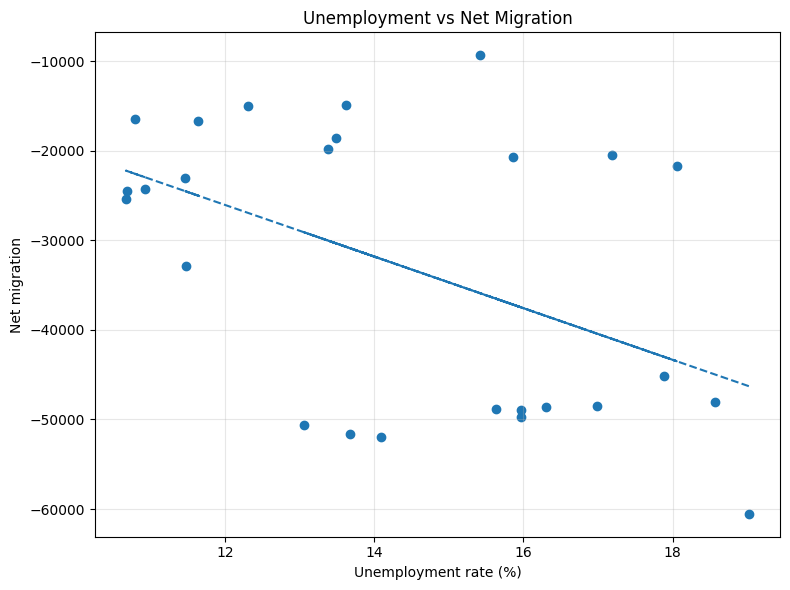

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\visuals\scatter_unemployment_vs_net_migration.png


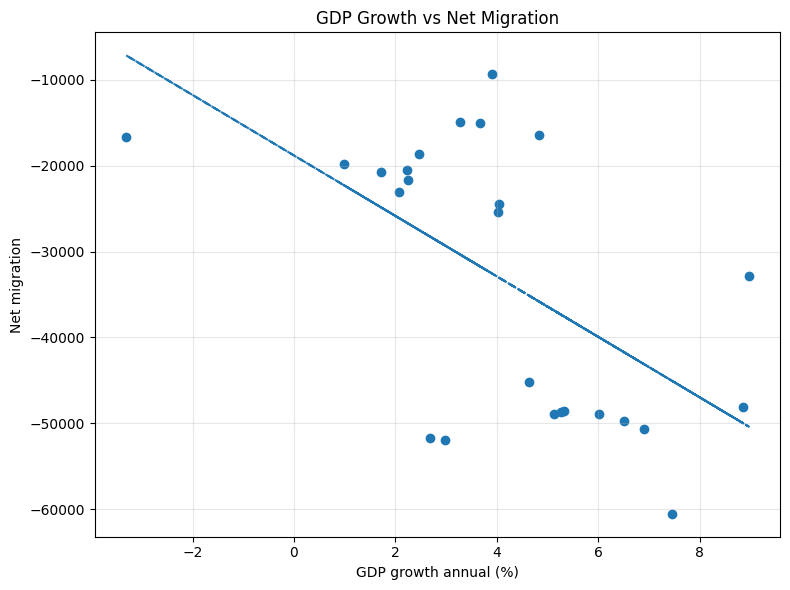

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\visuals\scatter_gdp_growth_vs_net_migration.png


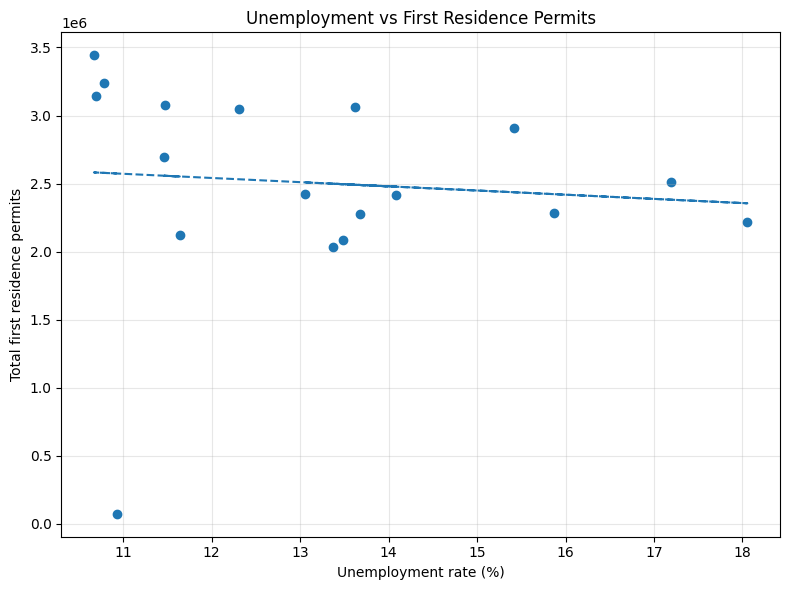

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\visuals\scatter_residence_permits_vs_unemployment.png


In [20]:
create_scatter_plot(
    analysis_df,
    "unemployment_total_percent",
    "net_migration",
    "Unemployment vs Net Migration",
    "Unemployment rate (%)",
    "Net migration",
    "scatter_unemployment_vs_net_migration.png"
)

create_scatter_plot(
    analysis_df,
    "gdp_growth_annual_percent",
    "net_migration",
    "GDP Growth vs Net Migration",
    "GDP growth annual (%)",
    "Net migration",
    "scatter_gdp_growth_vs_net_migration.png"
)

create_scatter_plot(
    analysis_df,
    "unemployment_total_percent",
    "total_first_residence_permits",
    "Unemployment vs First Residence Permits",
    "Unemployment rate (%)",
    "Total first residence permits",
    "scatter_residence_permits_vs_unemployment.png"
)

## Create Business-Language Summary

In [21]:
def make_business_interpretation(row):
    x = row["x_variable"]
    y = row["y_variable"]
    r = row["pearson_r"]
    p = row["pearson_p_value"]
    
    strength = correlation_strength(r)
    direction = correlation_direction(r)
    
    if p < 0.05:
        significance_text = "The relationship is statistically significant at the 5% level."
    else:
        significance_text = "The relationship is not statistically significant at the 5% level."
    
    if y == "net_migration":
        migration_note = (
            "Because net migration can be negative, the direction must be interpreted carefully: "
            "a lower net migration value usually means stronger migration pressure."
        )
    else:
        migration_note = ""
    
    return (
        f"For {x} and {y}, the Pearson correlation is {r}, which suggests a "
        f"{strength} {direction} relationship. {significance_text} {migration_note}"
    )


business_summaries = []

for _, row in correlation_results_df.iterrows():
    business_summaries.append(make_business_interpretation(row))

for summary in business_summaries:
    print("-", summary)

- For unemployment_total_percent and net_migration, the Pearson correlation is -0.4857, which suggests a moderate negative relationship. The relationship is statistically significant at the 5% level. Because net migration can be negative, the direction must be interpreted carefully: a lower net migration value usually means stronger migration pressure.
- For gdp_growth_annual_percent and net_migration, the Pearson correlation is -0.5791, which suggests a moderate negative relationship. The relationship is statistically significant at the 5% level. Because net migration can be negative, the direction must be interpreted carefully: a lower net migration value usually means stronger migration pressure.
- For gdp_per_capita_current_usd and net_migration, the Pearson correlation is 0.5753, which suggests a moderate positive relationship. The relationship is statistically significant at the 5% level. Because net migration can be negative, the direction must be interpreted carefully: a lower 

## Generate Statistical Report

In [22]:
def df_to_markdown_safe(df):
    try:
        return df.to_markdown(index=False)
    except Exception:
        return df.to_string(index=False)


report_path = REPORTS_DIR / "statistical_analysis_report.md"

report_lines = []

report_lines.append("# Statistical Analysis Report")
report_lines.append("")
report_lines.append("## Project")
report_lines.append("")
report_lines.append("Albania’s Brain Drain: A Data-Driven Analysis of Migration, Employment and Economic Development")
report_lines.append("")
report_lines.append("## Purpose")
report_lines.append("")
report_lines.append("This report analyzes whether migration indicators are statistically related to economic and employment indicators.")
report_lines.append("")
report_lines.append("The analysis uses Pearson correlation, Spearman correlation, p-values, and basic hypothesis testing.")
report_lines.append("")
report_lines.append("Important: correlation does not prove causation.")
report_lines.append("")

report_lines.append("## Correlation Results")
report_lines.append("")
report_lines.append(df_to_markdown_safe(correlation_results_df))
report_lines.append("")

report_lines.append("## Business-Language Interpretation")
report_lines.append("")
for summary in business_summaries:
    report_lines.append(f"- {summary}")
report_lines.append("")

report_lines.append("## Hypothesis Test 1: Unemployment and Net Migration")
report_lines.append("")
report_lines.append("H0: There is no statistically significant relationship between unemployment and net migration in Albania.")
report_lines.append("")
report_lines.append("H1: There is a statistically significant relationship between unemployment and net migration in Albania.")
report_lines.append("")

if not hypothesis_1.empty:
    row = hypothesis_1.iloc[0]
    decision = "Reject H0" if row["pearson_p_value"] < 0.05 else "Fail to reject H0"
    report_lines.append(f"Pearson r: {row['pearson_r']}")
    report_lines.append(f"p-value: {row['pearson_p_value']}")
    report_lines.append(f"Decision: {decision}")
report_lines.append("")

report_lines.append("## Hypothesis Test 2: GDP Growth and Net Migration")
report_lines.append("")
report_lines.append("H0: There is no statistically significant relationship between GDP growth and migration pressure.")
report_lines.append("")
report_lines.append("H1: There is a statistically significant relationship between GDP growth and migration pressure.")
report_lines.append("")

if not hypothesis_2.empty:
    row = hypothesis_2.iloc[0]
    decision = "Reject H0" if row["pearson_p_value"] < 0.05 else "Fail to reject H0"
    report_lines.append(f"Pearson r: {row['pearson_r']}")
    report_lines.append(f"p-value: {row['pearson_p_value']}")
    report_lines.append(f"Decision: {decision}")
report_lines.append("")

report_lines.append("## Limitations")
report_lines.append("")
report_lines.append("- The number of yearly observations may be limited for some indicators.")
report_lines.append("- Correlation does not prove causation.")
report_lines.append("- Net migration values require careful interpretation because negative values indicate migration loss.")
report_lines.append("- Eurostat migration and residence permit data are proxy indicators, not direct measures of all emigration from Albania.")
report_lines.append("- Missing values and different source coverage may affect statistical strength.")
report_lines.append("")

report_lines.append("## Visuals Created")
report_lines.append("")
report_lines.append("- scatter_unemployment_vs_net_migration.png")
report_lines.append("- scatter_gdp_growth_vs_net_migration.png")
report_lines.append("- scatter_residence_permits_vs_unemployment.png")
report_lines.append("")

with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Saved:", report_path)

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\reports\statistical_analysis_report.md


## Check outputs

In [23]:
print("Reports:")
for file in REPORTS_DIR.glob("*statistical*"):
    print("-", file.name)

print("\nVisuals:")
for file in VISUALS_DIR.glob("scatter_*.png"):
    print("-", file.name)

print("\nProcessed:")
for file in PROCESSED_DIR.glob("*statistical*"):
    print("-", file.name)

Reports:
- statistical_analysis_report.md

Visuals:
- scatter_gdp_growth_vs_net_migration.png
- scatter_residence_permits_vs_unemployment.png
- scatter_unemployment_vs_net_migration.png

Processed:
- statistical_correlation_results.csv
